# AP 155 Lab Exercise
---
## Exercise 3: Numbers | Horner's method

_Instructions_: 
- **Report discussion:** Address the following prompts.
    - Compare the rounding error patterns and output stability of Horner's method versus the naive power evaluation.
    - Explain why algebraically identical expressions (e.g., the two expressions of polynomials in problem 1, or the three ways we expressed the same function in problem 2) produce different numerical values when implemented in floating-point arithmetic.
    - Discuss how algorithmic redesign (such as Horner's rule or expression restructuring) mitigates floating-point error accumulation.
- **Report figure (to be reflected in code) (Problem 2):** Create a $2 \times 3$ grid of subplots comparing evaluations of the rational function $r(x)$:
    - Columns (3 Methods): Naive method (using direct powers), Horner's method, Rewritten form $s(x)$
    - Rows (2 values of $x$-points) $x= 1.606 + 2^{-52}$ and $2.400 + 2^{-52}i$ where $i\in[0,800]$.
  
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Botron, Christan Jake
- _Student No._: 2024-10168
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Discussion 

From the generated figures, we can see that both the naive evaluation and Horner's rule suffer from catastrophic subtractive cancellation at microscopic scales, yielding scattered noise. While the error is somewhat mitigated and predictable with Horner's method, it still lacks complete numerical stability. These algebraically identical expressions produce different numerical values because computers evaluate them using finite floating-point arithmetic. Since floating-point math lacks strict associativity, the exact sequence of operations dictates the final output. The standard polynomial expansion calculates massive individual terms of alternating signs, forcing the subtraction of nearly equal quantities, which ultimately destroys significant digits. Algorithmic redesign heavily mitigates this error accumulation. Horner’s rule minimizes total operations and avoids large intermediate exponentiations. Furthermore, explicitly rewriting functions to use factored terms and sums of squares purposefully avoids subtracting large, nearly equal floating-point numbers altogether. This restructuring prevents catastrophic cancellation, thereby preserving mathematical precision where standard evaluations fail. Furthermore, these redesigns improve the efficiency of the code, as seen in the code timing section.

---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1:

This problem discussed error buildup when trying to evaluate polynomials without and with the use of *Horner's Rule*. Take a polynomial of degree $n-1$:
$$ P(x) = p_0 + p_1x + p_2x^2 + p_3x^3 + ... + p_{n-1}x^{n-1}. $$

Write a function that takes in a list containing the $p_i$'s, say `coeffs`, and the point $x$ and evaluates the value of $P(x)$ in the naive way, i.e. from left to right.

Notice that this way of coding up the polynomial contains several (needless) multiplications. This is so because $x^i$ is evaluated as $x\times x\times ... \times x$ (where there are $i-1$ multiplications). Thus, this way of approaching the problem corresponds to
$$ 1 + 2 + ... + n-2 = \frac{(n-1)(n-2)}{2}$$
multiplications, from $x^2$ all the way up to $x^{n-1}$. 

Let `coeffs=[(-11)**i for i in reversed(range(8))]` and `x = 11.01`

In [2]:
coeffs= [(-11)**i for i in reversed(range(8))]
x = 11.01

In [3]:
def eval_naive(coeffsList, x):
    """evaluate naively from left to right, using the power/exponent operations"""
    P = 0
    for i, p in enumerate(coeffsList):
        P += p * (x**i)
    return P

eval_naive(coeffs, x)

71056.02362162992

# If we write the polynomial: 
$$ P(x) = p_0 + x(p_1 + x(p_2 + x(p_3 + ... + x(p_{n-2} + xp_{n-1})...))) \tag{1}$$

then we can get away with only $n-1$ multiplications (i.e., no powers are evaluated). This is obviously more efficient, but equally important is the fact that this way we can substantially limit the accumulation of rounding error (especially for polynomials of large degree).

Write a function that takes in a list containing the $p_i$'s, say `coeffs`  and the point $x$ and evaluates the value of $P(x)$ in a new way, i.e., from right to left.

In [4]:
def eval_horner(coeffsList, x):
    """using Horner's rule from right to left"""
    val = 0
    for i, p in enumerate(reversed(coeffsList)):
        val = p + x*val
    return val

eval_horner(coeffs, x)

71056.02362163365

Try timing the code and compare (Shift enter the next two cells)

In [5]:
%timeit eval_horner(coeffs, x)

1.49 μs ± 83 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [6]:
%timeit eval_naive(coeffs, x)

2.57 μs ± 248 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


Apply the previous two functions to the (admittedly artificial) case of:
`coeffs=[(-11)**i for i in reversed(range(8))]` and $x=11.01$. Observe any discrepancy and discuss its origin.

In [7]:
naive_val = eval_naive(coeffs, x)
horner_val = eval_horner(coeffs, x)

print(f"Naive evaluation:   {naive_val}")
print(f"Horner's evaluation: {horner_val}")
print(f'Error: {100 * (horner_val - naive_val)/horner_val}%') # use absolute error over max value 

'''
Naive evaluation:   71056.02362162992
Horner's evaluation: 71056.02362163365
Error: 5.242750872605424e-12%
'''

Naive evaluation:   71056.02362162992
Horner's evaluation: 71056.02362163365
Error: 5.242750872605424e-12%


"\nNaive evaluation:   71056.02362162992\nHorner's evaluation: 71056.02362163365\nError: 5.242750872605424e-12%\n"

#### Problem 1 code summary

The code compares standard term-by-term summation (w/ exponentiation) against Horner’s rule in terms of computational efficiency and precision. Horner’s method is implemented iteratively from right to left (val = p + x * val) to eliminate redundant exponentiation. This reduces the big O notation from $n^2$ to $n$ which is less complex and, thus, more efficient. Furthermore, by factoring out $x$ sequentially rather than calculating massive individual terms of alternating signs, we avoid severe subtractive cancellation between nearly equal quantities which preserves precision.

---

### Problem 2:

This problem studies the rational function introduced in the main text, Eq. (2.53).

$$ r(x) = \frac{4x^4 - 59x^3 + 324 x^2 - 751x + 622}{x^4 - 14x^3 + 72x^2 - 151x + 112} \tag{2}$$

(a) Apply Horner’s rule twice (once for the numerator and once for the denominator) to produce two plots, one for $x = 1.606 + 2^{−52}i$ and one for $x = 2.400 + 2^{−52}i$. Your results should look like Fig. 2.3.


- To replicate Figure 2.3, $i$ is an array from 0 to 800 with dtype np.float64
- This means $x$ should be an array as well

In [8]:
import matplotlib.pyplot as plt
import numpy as np

num_coeffs = [622, -751, 324, -59, 4]
den_coeffs = [112, -151, 72, -14, 1]

i = np.arange(0, 801, dtype = np.float64)

x1 = 1.606 + i*2**(-52)
x2 = 2.400 + i*2**(-52)

#We will use these variables for the rest of the code below

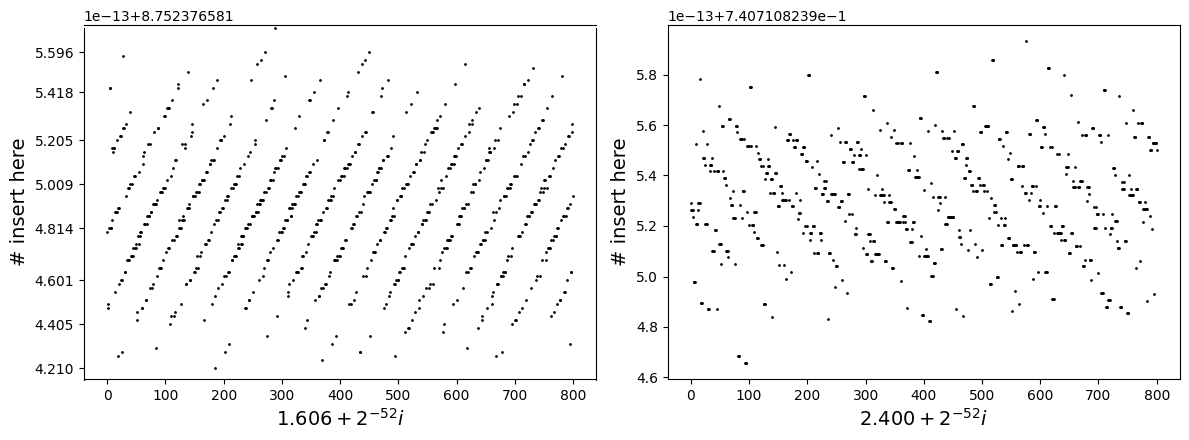

In [9]:
#Applying horner's rule in numerator and denominator
y1 = eval_horner(num_coeffs, x1) / eval_horner(den_coeffs, x1)
y2 = eval_horner(num_coeffs, x2) / eval_horner(den_coeffs, x2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.scatter(i, y1, s=1, c='k')
ax1.set_xlabel(r'$1.606 + 2^{-52}i$', fontsize=14)
ax1.set_ylabel(r'# insert here', fontsize=14)
ax1.set_ylim(bottom=min(y1), top=max(y1))

ax2.scatter(i, y2, s=1, c='k')
ax2.set_xlabel(r'$2.400 + 2^{-52}i$', fontsize=14)
ax2.set_ylabel(r'# insert here', fontsize=14)

plt.tight_layout()

#The output should look like figure 3. 
#The y-axis could be confusing the but there's a number on top that ...
#...tells the order of magnitude and the offset of the tick marks on the y-axis

(b) Create a new Python function that codes up the following expression:
$$ s(x)= 4− \frac{3(x−2)[(x−5)^2 + 4]}{x + (x−2)^2[(x−5)^2 + 3]}$$
which is a rewritten version of our rational function. Apply this new function for
the previous two plots and compare the rounding error pattern, size, etc.

In [10]:
def s(x):
    num = 3* (x-2) * ((x-5)**2+4)
    den = x + (x-2)**2 * ((x-5)**2+3)
    return 4 - num/den

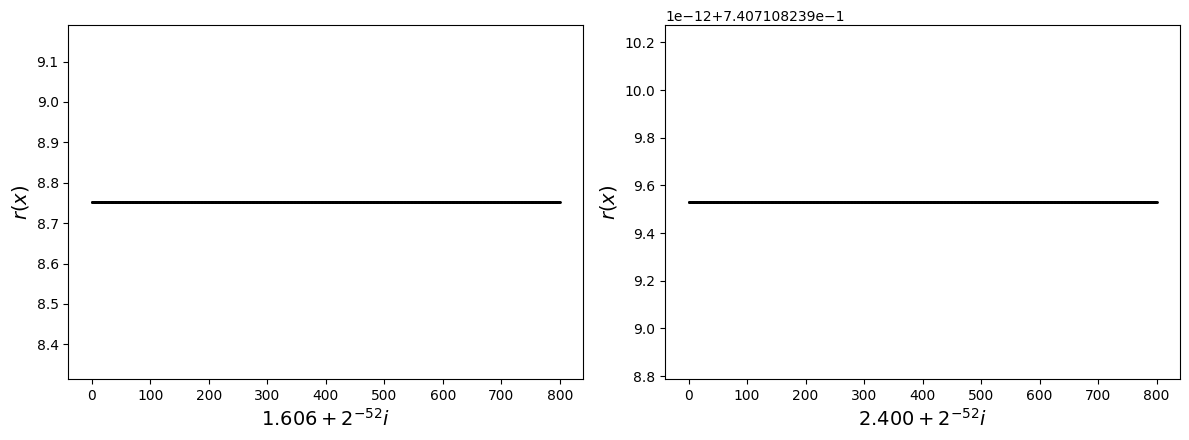

In [11]:

#using x1 and x2 from earlier
y1 = s(x1)
y2 = s(x2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.scatter(i, y1, s=1, c='k')
ax1.set_xlabel(r'$1.606 + 2^{-52}i$', fontsize=14)
ax1.set_ylabel(r'$r(x)$', fontsize=14)
ax1.set_ylim(bottom=min(y1), top=max(y1))

ax2.scatter(i, y2, s=1, c='k')
ax2.set_xlabel(r'$2.400 + 2^{-52}i$', fontsize=14)
ax2.set_ylabel(r'$r(x)$', fontsize=14)

plt.tight_layout()

(c) Now introduce two more sets of results, this time for the starting expression for $r(x)$ produced using (not Horner’s rule but) the naive implementation, using powers (i.e., the way you would have coded this up before doing problem 2.11).
Interpret your findings.

- Note: use the earlier function in problem 1 in the naive evaluation

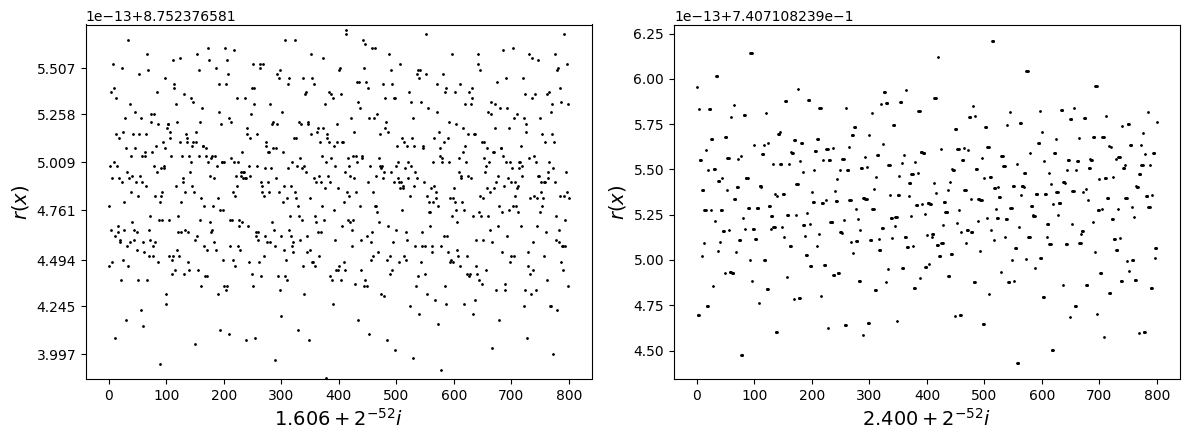

In [12]:
import matplotlib.pyplot as plt
import numpy as np

num_coeffs = [622, -751, 324, -59, 4]
den_coeffs = [112, -151, 72, -14, 1]

#Using x1 and x2 from earlier

y1 = eval_naive(num_coeffs, x1) / eval_naive(den_coeffs, x1)
y2 = eval_naive(num_coeffs, x2) / eval_naive(den_coeffs, x2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.scatter(i, y1, s=1, c='k')
ax1.set_xlabel(r'$1.606 + 2^{-52}i$', fontsize=14)
ax1.set_ylabel(r'$r(x)$', fontsize=14)
ax1.set_ylim(bottom=min(y1), top=max(y1))

ax2.scatter(i, y2, s=1, c='k')
ax2.set_xlabel(r'$2.400 + 2^{-52}i$', fontsize=14)
ax2.set_ylabel(r'$r(x)$', fontsize=14)

plt.tight_layout()

Let's summarize all outputs (6 of them) into a 2 row by 3 column plot

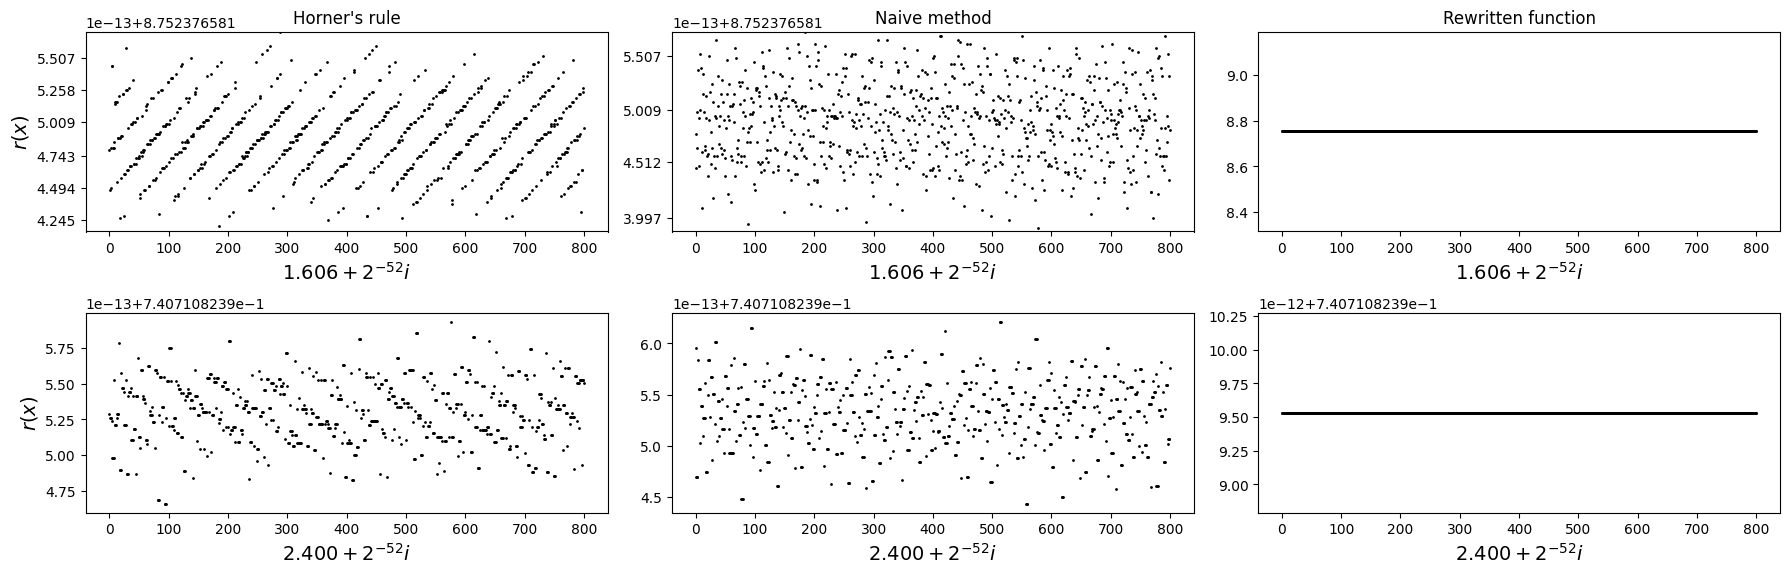

In [21]:
# summarize all subplots

#We use the previously defined variables of num_coeffs, den_coeffs, x1, x2, and i
#We use the previously defined functions of eval_horner, eval_naive, and s

y_horner_x1 = eval_horner(num_coeffs, x1) / eval_horner(den_coeffs, x1)
y_horner_x2 = eval_horner(num_coeffs, x2) / eval_horner(den_coeffs, x2)
y_naive_x1 = eval_naive(num_coeffs, x1) / eval_naive(den_coeffs, x1)
y_naive_x2 = eval_naive(num_coeffs, x2) / eval_naive(den_coeffs, x2)
y_good_x1 = s(x1)
y_good_x2 = s(x2)

arrays = [y_horner_x1, y_naive_x1, y_good_x1, y_horner_x2, y_naive_x2, y_good_x2]
y_min = np.min(arrays)
y_max = np.max(arrays)

fig, axs = plt.subplots(2, 3, figsize=(6*3, 6))

axs[0, 0].scatter(i, y_horner_x1, s=1, c='k')
axs[0, 0].set_ylim(min(y_horner_x1), max(y_horner_x1))
axs[1, 0].scatter(i, y_horner_x2, s=1, c='k')
axs[0, 0].set_title("Horner's rule")
axs[0, 0].set_xlabel(r'$1.606 + 2^{-52}i$', fontsize=14)
axs[1, 0].set_xlabel(r'$2.400 + 2^{-52}i$', fontsize=14)
axs[0, 0].set_ylabel(r'$r(x)$', fontsize=14)
axs[1, 0].set_ylabel(r'$r(x)$', fontsize=14)

axs[0, 1].scatter(i, y_naive_x1, s=1, c='k')
axs[0, 1].set_ylim(min(y_naive_x1), max(y_naive_x1))
axs[1, 1].scatter(i, y_naive_x2, s=1, c='k')
axs[0, 1].set_title("Naive method")
axs[0, 1].set_xlabel(r'$1.606 + 2^{-52}i$', fontsize=14)
axs[1, 1].set_xlabel(r'$2.400 + 2^{-52}i$', fontsize=14)

axs[0, 2].scatter(i, y_good_x1, s=1, c='k')
axs[0, 2].set_ylim(min(y_good_x1), max(y_good_x1))
axs[1, 2].scatter(i, y_good_x2, s=1, c='k')
axs[0, 2].set_title("Rewritten function")
axs[0, 2].set_xlabel(r'$1.606 + 2^{-52}i$', fontsize=14)
axs[1, 2].set_xlabel(r'$2.400 + 2^{-52}i$', fontsize=14)

plt.tight_layout()


#### Problem 2 code summary

My code compares the numerical stability of three evaluation methods across microscophic perturbations in a given rational function, namely: naive expansion, Horner's rule, and an algebraically rewritten form. From the figure, we can see that both evaluation techniques (naive and Horner's rule) suffer from catastrophic subtractive cancellation at this scale, producing completely scattered noise. While the noise was somewhat mitigated and is thus predictable by using Horner's rule, it is still far from the result of explicitly coding the rewritten function $s(x)$ to use factored terms and sums of squares. The implementation purposefully avoided subtracting large, nearly equal floating-point numbers, thus preserving mathematical precision.

---